In [ ]:
import math

In [8]:
def calculate_mean(data_list):
    """
    Calculates the arithmetic mean: sum of values / number of values
    This is equivalent to np.mean(data_list)
    """
    return sum(data_list) / len(data_list)

def calculate_standard_deviation(data_list):
    """
    Calculates the statistical residual (standard deviation)
    This is equivalent to np.std(data_list)
    """
    mean = calculate_mean(data_list)
    n = len(data_list)
    # Sum of squared differences from the mean
    squared_diff_sum = sum((x - mean)**2 for x in data_list)
    # Sample variance (using n-1)
    variance = squared_diff_sum / (n - 1)
    return math.sqrt(variance)

def calculate_uncertainty_of_mean(data_list):
    """
    Calculates the statistical uncertainty on the mean (sigma / sqrt(n))
    This is equivalent to np.std(data_list)/np.sqrt(len(data_list))
    """
    std_dev = calculate_standard_deviation(data_list)
    return std_dev / math.sqrt(len(data_list))

In [55]:
# --- MEASUREMENT DATA ---
# 1.3.2 Measurements
# 1. Pendulum Length (l) in meters and its estimated uncertainty
L = 0.387
u_L = 0.005

# 2. Time Measurements
# (a) Mechanical stopwatch: Single cycle (T)
times_a = [1.2, 1.2, 1.2, 1.1, 1.1, 1.1]
mean_times_a = calculate_mean(times_a)
std_times_a = calculate_standard_deviation(times_a)
unc_times_a = calculate_uncertainty_of_mean(times_a)
print(f"Single cycles with mechanical stop watch")
print(f"Mean time = {mean_times_a:.3}")
print(f"Standard deviation = {std_times_a:.3}")
print(f"Statistical uncertainty = {unc_times_a:.3}")

# (b) Electronic stopwatch: Single cycle (T)
times_b = [1,1, 0.99]
mean_times_b = calculate_mean(times_b)
std_times_b = calculate_standard_deviation(times_b)
unc_times_b = calculate_uncertainty_of_mean(times_b)
print(f"Single cycles with electronic stop watch")
print(f"Mean time = {mean_times_b:.3}")
print(f"Standard deviation = {std_times_b:.3}")
print(f"Statistical uncertainty = {unc_times_b:.3}")

# (c) Mechanical stopwatch: Five cycles (5*T)
times_c_5cycles = [6.72, 6.66, 6.51]
mean_times_c_5cycles = calculate_mean(times_c_5cycles)/5
std_times_c_5cycles = calculate_standard_deviation(times_c_5cycles)
unc_times_c_5cycles = calculate_uncertainty_of_mean(times_c_5cycles)
print(f"5 cycles with mechanical stop watch")
print(f"Mean time = {mean_times_c_5cycles:.3}")
print(f"Standard deviation = {std_times_c_5cycles:.3}")
print(f"Statistical uncertainty = {unc_times_c_5cycles:.3}")

# (d) Electronic stopwatch: Five cycles (5*T)
times_d_5cycles = [5.02, 5, 4.93]
mean_times_d_5cycles = calculate_mean(times_d_5cycles)/5
std_times_d_5cycles = calculate_standard_deviation(times_d_5cycles)
unc_times_d_5cycles = calculate_uncertainty_of_mean(times_d_5cycles)
print(f"5 cycles with electronic stop watch")
print(f"Mean time = {mean_times_d_5cycles:.3}")
print(f"Standard deviation = {std_times_d_5cycles:.3}")
print(f"Statistical uncertainty = {unc_times_d_5cycles:.3}")

Single cycles with mechanical stop watch
Mean time = 1.15
Standard deviation = 0.0548
Statistical uncertainty = 0.0224
Single cycles with electronic stop watch
Mean time = 0.997
Standard deviation = 0.00577
Statistical uncertainty = 0.00333
5 cycles with mechanical stop watch
Mean time = 1.33
Standard deviation = 0.108
Statistical uncertainty = 0.0624
5 cycles with electronic stop watch
Mean time = 0.997
Standard deviation = 0.0473
Statistical uncertainty = 0.0273


In [52]:
# --- SYSTEMATIC UNCERTAINTIES ---
# Based on device specifications (accuracy of the clock/scale)
u_sys_mech = 0.2  # systematic error for mechanical
u_sys_elec = 0.01  # systematic error for electronic
u_sys_human = 0.1 # systematic error from the human

m_sys_elec_tot = math.sqrt(u_sys_elec**2 + u_sys_human**2)
m_sys_mech_tot = math.sqrt(u_sys_mech**2 + u_sys_human**2)
print(f"The systematic mechanic error is {m_sys_mech_tot:.3}")
print(f"The systematic electronic error is {m_sys_elec_tot:.3} ")

m_tot_a = math.sqrt(m_sys_mech_tot**2 + unc_times_a**2)
m_rel_a = m_tot_a/mean_times_a
print(f"Period for (a): {mean_times_a:.3} with abs unc {m_tot_a:.3} and rel unc {m_rel_a:.3}")

m_tot_b = math.sqrt(m_sys_elec_tot**2 + unc_times_b**2)
m_rel_b = m_tot_b/mean_times_b
print(f"Period for (b): {mean_times_b:.3} with abs unc {m_tot_b:.3} and rel unc {m_rel_b:.3}")

m_tot_c = math.sqrt(m_sys_mech_tot**2 + unc_times_c_5cycles**2)
m_rel_c = m_tot_c/mean_times_c_5cycles
print(f"Period for (c): {mean_times_c_5cycles:.3} with abs unc {m_tot_c:.3} and rel unc {m_rel_c:.3}")

m_tot_d = math.sqrt(m_sys_elec_tot**2 + unc_times_d_5cycles**2)
m_rel_d = m_tot_d/mean_times_d_5cycles
print(f"Period for (d): {mean_times_d_5cycles:.3} with abs unc {m_tot_d:.3} and rel unc {m_rel_d:.3}")


The systematic mechanic error is 0.224
The systematic electronic error is 0.1 
Period for (a): 1.15 with abs unc 0.225 and rel unc 0.195
Period for (b): 0.997 with abs unc 0.101 and rel unc 0.101
Period for (c): 1.33 with abs unc 0.232 and rel unc 0.175
Period for (d): 1.66 with abs unc 0.104 and rel unc 0.0627


In [53]:
def evaluate_method(raw_times, cycles, u_sys_t, length, u_sys_l):
    # Convert raw measurements to the period of a single cycle T
    periods = [t / cycles for t in raw_times]

    T_mean = calculate_mean(periods)
    u_stat = calculate_uncertainty_of_mean(periods)

    # Total uncertainty on T (combined in quadrature)
    u_T_total = math.sqrt(u_stat**2 + u_sys_t**2)

    # Calculate g using Eq 1.2
    g_calc = (4 * (math.pi**2) * length) / (T_mean**2)

    # Relative uncertainty propagation for g
    err_prop_T = u_T_total*8*math.pi**2*length/T_mean**3
    err_prop_l = u_sys_l*4*math.pi**2/T_mean**2
    u_g_total = math.sqrt(err_prop_T**2 + err_prop_l**2)

    return g_calc, u_g_total, T_mean, u_T_total

In [54]:
print(f"Results with measurements form (d)")
g, m_g, t, m_t = evaluate_method(times_d_5cycles, 5, m_sys_elec_tot, L, u_L)
print(f"Period: T = {t:.3} +/- {m_t:.3}")
print(f"Length: L = {L:.3} +/- {u_L:.3}")
print(f"Gravity: g = {g:.3} +/- {m_g:.3}")

Results with measurements form (d)
Period: T = 0.997 +/- 0.101
Length: L = 0.387 +/- 0.005
Gravity: g = 15.4 +/- 3.11


In [58]:
# Length dependency of T
L_1 = 0.365
T_1 = [5.88, 5.9, 5.85]
g_1, m_g_1, t_1, m_t_1 = evaluate_method(T_1, 5, m_sys_elec_tot, L_1, u_L)
L_2 = 0.83
T_2 = [9.09, 9.02, 9.08]
g_2, m_g_2, t_2, m_t_2 = evaluate_method(T_2, 5, m_sys_elec_tot, L_2, u_L)
L_3 = 0.44
T_3 = [6.72, 6.66, 6.51]
g_3, m_g_3, t_3, m_t_3 = evaluate_method(T_3, 5, m_sys_elec_tot, L_3, u_L)
L_4 = 0.675
T_4 = [8.33, 8.32, 8.33]
g_4, m_g_4, t_4, m_t_4 = evaluate_method(T_4, 5, m_sys_elec_tot, L_4, u_L)
lengths = [L_1, L_2, L_3, L_4]
m_lengths = [u_L, u_L, u_L, u_L]
times = [t_1, t_2, t_3, t_4]
m_times = [m_t_1, m_t_2, m_t_3, m_t_4]
gs = [g_1, g_2, g_3, g_4]
m_gs = [m_g_1, m_g_2, m_g_3, m_g_4]

for g, m_g in zip(gs, m_gs):
    print(f"Gravity: g = {g} +/- {m_g}")

Gravity: g = 10.431109266445466 +/- 1.7903144167335587
Gravity: g = 9.972451481366871 +/- 1.1084699246769822
Gravity: g = 9.87928160648116 +/- 1.5132104970190003
Gravity: g = 9.6086231253406 +/- 1.1619209015777128


In [ ]:
import matplotlib.pyplot as plt

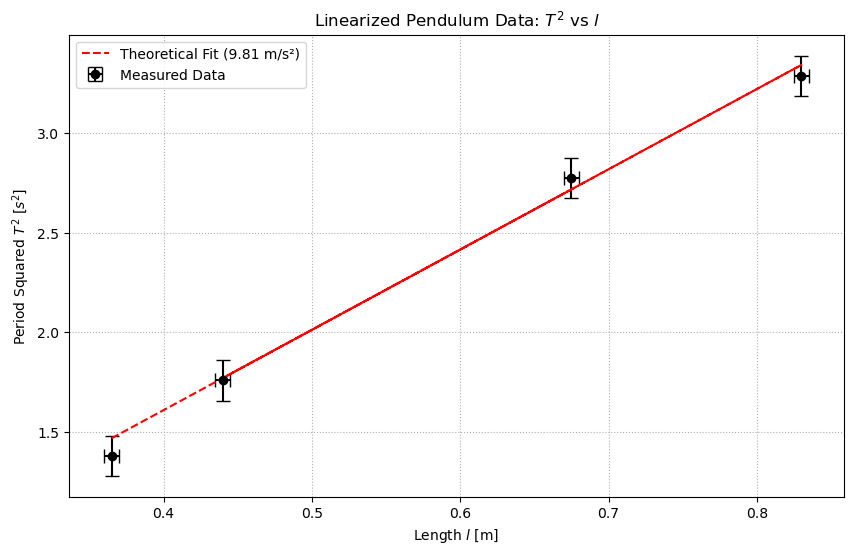

In [59]:
times_sqrd = [t**2 for t in times]
# Data for plotting (Multiple lengths l and corresponding T^2)
plt.figure(figsize=(10, 6))
plt.errorbar(lengths, times_sqrd,xerr=m_lengths, yerr=m_times, fmt='ko', capsize=5, label='Measured Data')

# Theoretical line for comparison (g = 9.81 m/s^2)
g_expected = 9.81
theoretical_slope = (4 * math.pi**2) / g_expected
plt.plot(lengths, [theoretical_slope * l for l in lengths], 'r--', label='Theoretical Fit (9.81 m/s²)')

plt.xlabel('Length $l$ [m]')
plt.ylabel('Period Squared $T^2$ [$s^2$]')
plt.title('Linearized Pendulum Data: $T^2$ vs $l$')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

In [ ]:
from scipy.optimize import curve_fit
import numpy as np

Experimental Slope (m): 4.1635 +/- 0.1718
Y-Intercept (c): -0.1059 +/- 0.0510 (Ideally close to 0)
Calculated Gravitational Acceleration (g): 9.482 +/- 0.3912 m/s^2


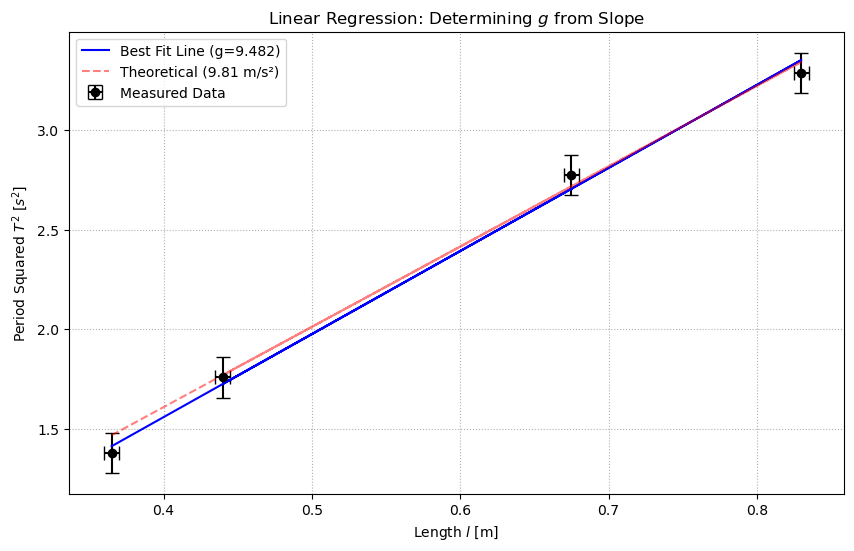

In [60]:
# Calculate the slope:
def linear_fun(x, m, c):
    return m * x + c


# Apply the fit to measured data
popt, pcov = curve_fit(f = linear_fun,
                       xdata = lengths,
                       ydata = times_sqrd,
                       sigma = m_times*np.sqrt(times_sqrd),
                       absolute_sigma = True,
                       )

m, c = popt
m_err, c_err = np.diag(pcov)
# Calculate experimental 'g' from the slope
# Since slope m = 4*pi^2 / g  => g = 4*pi^2 / m
g_experimental = (4 * (math.pi**2)) / m
g_err = (4 * np.pi**2 / m**2) * m_err

print(f"Experimental Slope (m): {m:.4f} +/- {m_err:.4f}")
print(f"Y-Intercept (c): {c:.4f} +/- {c_err:.4f} (Ideally close to 0)")
print(f"Calculated Gravitational Acceleration (g): {g_experimental:.3f} +/- {g_err:.4f} m/s^2")

# Visualization
plt.figure(figsize=(10, 6))

# Plot the raw data with error bars
plt.errorbar(lengths, times_sqrd, xerr=m_lengths, yerr=m_times,
             fmt='ko', capsize=5, label='Measured Data')

# Create the Best Fit Line using the calculated m and c
plt.plot(lengths, [(m * l + c) for l in lengths], 'b-', label=f'Best Fit Line (g={g_experimental:.3f})')

# Theoretical line for comparison (g = 9.81)
g_expected = 9.81
theo_slope = (4 * math.pi**2) / g_expected
plt.plot(lengths, [theo_slope * l for l in lengths], 'r--', alpha=0.5, label='Theoretical (9.81 m/s²)')

plt.xlabel('Length $l$ [m]')
plt.ylabel('Period Squared $T^2$ [$s^2$]')
plt.title('Linear Regression: Determining $g$ from Slope')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()